In [1]:
import os
os.chdir("..")
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

In [2]:
FEATURE_COLS = ["hr", "hrv", "eda", "wrist_temp", "co2_noisy", "lux_noisy", "posture_cm"]
df = pd.read_csv("outputs/unified_features.csv").dropna(subset=FEATURE_COLS)

le = LabelEncoder()
y = le.fit_transform(df["ground_truth"])
groups = df["subject"].values

In [3]:
from sklearn.model_selection import StratifiedGroupKFold

def run_cv(feature_cols, df, y, groups, n_repeats=10):
    X = df[feature_cols].values
    fold_f1 = []
    for repeat in range(n_repeats):
        sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=repeat)
        for train_idx, test_idx in sgkf.split(X, y, groups=groups):
            scaler = StandardScaler()
            Xtr = scaler.fit_transform(X[train_idx])
            Xte = scaler.transform(X[test_idx])
            clf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
            clf.fit(Xtr, y[train_idx])
            preds = clf.predict(Xte)
            fold_f1.append(f1_score(y[test_idx], preds, average="macro", zero_division=0))
    return np.mean(fold_f1)

baseline_f1 = run_cv(FEATURE_COLS, df, y, groups)
print(f"Baseline (all sensors working): F1 = {baseline_f1:.4f}\n")

dropout_results = {"all_sensors": baseline_f1}
for sensor in FEATURE_COLS:
    df_dropped = df.copy()
    df_dropped[sensor] = df_dropped[sensor].mean()
    f1 = run_cv(FEATURE_COLS, df_dropped, y, groups)
    dropout_results[f"without_{sensor}"] = f1
    drop_pct = (baseline_f1 - f1) / baseline_f1 * 100
    print(f"{sensor} fails: F1 = {f1:.4f}  (drop: {drop_pct:.1f}%)")

Baseline (all sensors working): F1 = 0.7306

hr fails: F1 = 0.6339  (drop: 13.2%)
hrv fails: F1 = 0.7315  (drop: -0.1%)
eda fails: F1 = 0.6840  (drop: 6.4%)
wrist_temp fails: F1 = 0.7431  (drop: -1.7%)
co2_noisy fails: F1 = 0.7356  (drop: -0.7%)
lux_noisy fails: F1 = 0.7326  (drop: -0.3%)
posture_cm fails: F1 = 0.7760  (drop: -6.2%)


In [4]:
results_df = pd.DataFrame(dropout_results.items(), columns=["Condition", "F1"])
results_df["F1_drop_pct"] = (baseline_f1 - results_df["F1"]) / baseline_f1 * 100
results_df = results_df.sort_values("F1_drop_pct", ascending=False)
results_df.to_csv("outputs/sensor_dropout_results.csv", index=False)
print(results_df.to_string(index=False))

         Condition       F1  F1_drop_pct
        without_hr 0.633882    13.237968
       without_eda 0.683968     6.382441
       all_sensors 0.730598     0.000000
       without_hrv 0.731473    -0.119640
 without_lux_noisy 0.732614    -0.275826
 without_co2_noisy 0.735570    -0.680440
without_wrist_temp 0.743102    -1.711470
without_posture_cm 0.775991    -6.213067


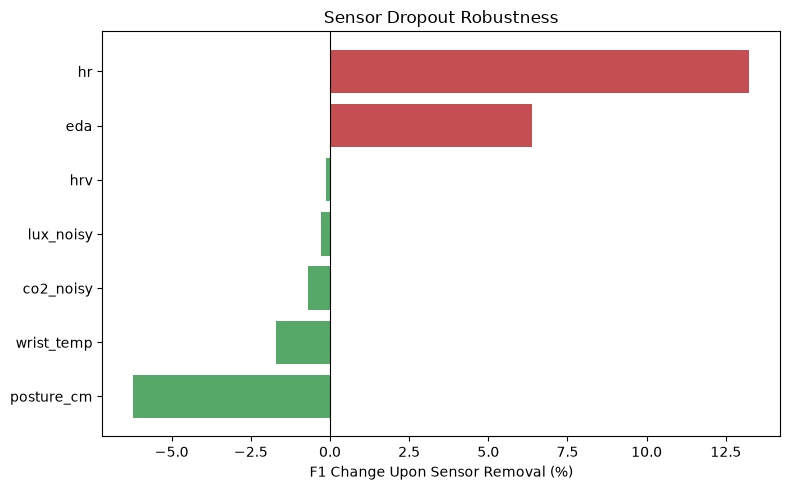

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("outputs/sensor_dropout_results.csv")
df = df[df["Condition"] != "all_sensors"].sort_values("F1_drop_pct", ascending=True)
labels = df["Condition"].str.replace("without_", "", regex=False)

colors = ["#C44E52" if v > 0 else "#55A868" for v in df["F1_drop_pct"]]

plt.figure(figsize=(8, 5))
plt.barh(labels, df["F1_drop_pct"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("F1 Change Upon Sensor Removal (%)")
plt.title("Sensor Dropout Robustness")
plt.tight_layout()
plt.savefig("outputs/figure5_sensor_dropout.png", dpi=300, bbox_inches="tight")
plt.show()